In [1]:
import numpy as np
from sklearn import metrics
import os
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
import pickle

In [3]:
y_true = [0] * 99 + [1] * 87
print(y_true)
print(len(y_true))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
186


In [4]:
# place raw data here

y_pred_ALLocate = [
    3.23, 1.82, 12.50, 3.85, 3.45, 0.00, 3.45, 0.00, 8.33, 0.00, 0.00,
    3.13, 0.00, 4.08, 0.00, 0.00, 3.70, 0.00, 2.78, 0.00, 0.00, 0.00,
    2.56, 20.00, 0.00, 2.13, 0.00, 1.75, 0.00, 0.00, 0.00, 2.33, 0.00,
    0.00, 0.00, 12.24, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 12.50, 0.00,
    0.00, 3.03, 0.00, 4.17, 0.00, 0.00, 3.03, 5.00, 2.38, 10.00, 0.00,
    0.00, 0.00, 22.22, 2.78, 0.00, 8.33, 0.00, 0.00, 10.00, 19.35, 2.22,
    1.72, 3.45, 0.00, 9.52, 0.00, 5.88, 5.00, 3.23, 9.52, 0.00, 0.00,
    8.70, 3.85, 0.00, 5.26, 0.00, 6.25, 0.00, 2.44, 0.00, 0.00, 3.70,
    12.00, 0.00, 0.00, 4.17, 0.00, 0.00, 0.00, 9.09, 0.00, 0.00, 0.00,
    0.0, 9.1, 14.3, 20.7, 50.0, 52.2, 41.7, 80.0, 17.6, 27.6, 9.7, 56.1,
    50.0, 30.8, 66.7, 25.0, 24.6, 61.5, 0.0, 55.2, 61.5, 54.5, 66.7, 0.0,
    69.2, 0.0, 52.6, 3.8, 80.0, 70.4, 61.5, 36.2, 55.6, 2.9, 0.0, 78.8,
    35.1, 23.9, 0.0, 17.9, 15.2, 25.0, 43.8, 71.4, 50.0, 65.7, 3.0, 24.6,
    22.2, 2.0, 40.9, 35.7, 80.4, 20.6, 0.0, 26.1, 24.3, 5.7, 15.4, 63.4,
    2.8, 24.2, 18.8, 2.8, 24.2, 65.8, 42.6, 34.9, 32.8, 41.4, 7.7, 17.4,
    33.3, 19.1, 45.8, 18.2, 46.2, 14.3, 58.8, 45.2, 1.3, 52.0, 50.0, 67.2,
    20.0, 51.9, 18.2
    ]
y_pred_path = [
    3.23, 1.82, 12.50, 3.85, 6.67, 0.00, 0.00, 0.00, 8.33, 0.00, 0.00,
    3.13, 0.00, 4.08, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    0.00, 11.11, 0.00, 0.00, 2.70, 0.00, 0.00, 2.33, 0.00, 0.00, 8.33,
    3.85, 2.56, 8.51, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    6.67, 3.03, 0.00, 4.17, 2.94, 0.00, 3.03, 5.00, 4.65, 0.00, 2.78,
    0.00, 0.00, 8.70, 2.78, 0.00, 4.35, 0.00, 0.00, 0.00, 16.67, 2.22,
    0.00, 0.00, 0.00, 7.32, 0.00, 5.88, 5.00, 3.23, 9.52, 0.00, 0.00,
    4.55, 3.85, 5.41, 0.00, 0.00, 6.25, 0.00, 0.00, 1.52, 5.56, 3.70,
    8.33, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    0.00, 31.03, 20.00, 14.81, 48.57, 47.62, 42.86, 75.00, 17.65, 27.59,
    26.32, 52.63, 50.00, 25.00, 69.23, 22.22, 29.23, 54.55, 10.47, 45.83,
    61.54, 58.33, 50.00, 1.89, 69.23, 3.90, 55.00, 3.85, 78.95, 70.37,
    59.46, 37.29, 55.56, 0.00, 2.08, 77.08, 36.84, 22.22, 0.00, 17.86,
    15.15, 28.26, 43.75, 71.43, 45.83, 63.64, 3.03, 28.33, 12.50, 4.00,
    38.10, 35.71, 79.07, 27.03, 0.00, 26.14, 22.22, 21.43, 28.26, 59.46,
    23.91, 37.50, 31.58, 20.45, 21.88, 64.86, 36.73, 31.71, 29.69, 37.04,
    7.69, 12.31, 39.13, 26.21, 45.83, 10.00, 46.15, 14.29, 58.82, 48.48,
    13.33, 58.62, 60.00, 65.45, 0.00, 48.00, 18.18
]

print(len(y_pred_ALLocate))
print(len(y_pred_path))

186
186


In [6]:
class_names = ["Adequate", "Blood", "Clot"]
y_true_arr = np.asarray(y_true, dtype=int)
y_pred_ALLocate_arr = np.asarray(y_pred_ALLocate, dtype=float)
y_pred_ALLocate_arr = y_pred_ALLocate_arr / 100.0

y_pred_path_arr = np.asarray(y_pred_path, dtype=float)
y_pred_path_arr = y_pred_path_arr / 100.0

fpr_list_AL, tpr_list_AL, thresholds_AL = roc_curve(y_true_arr, y_pred_ALLocate_arr)
auc_score_AL = roc_auc_score(y_true_arr, y_pred_ALLocate_arr)

fpr_list_path, tpr_list_path, thresholds_path = roc_curve(y_true_arr, y_pred_path_arr)
auc_score_path = roc_auc_score(y_true_arr, y_pred_path_arr)

In [ ]:
def plot_multi_roc(
        results_dict,
        figsize=(6, 5),
        colors=None,
        zoom_factor=1.2,
        zoom_location=2,
        zoom_bbox=(0.5, 0.9),
        zoom_xlim=(0, 0.1),
        zoom_ylim=(0.9, 1.0),
        show_std=True,
        label_fontsize=14,      # axis-label / legend text size
        tick_fontsize=12):      # tick-label size (main & inset)
    """
    Plot multiple ROC curves with optional σ-bands and a zoom inset.

    … (docstring unchanged apart from the two fontsize params) …
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

    if colors is None:
        colors = ['#8b91c1', '#d9a9cd', '#424874', '#e6d3ae']

    fig, ax = plt.subplots(figsize=figsize)

    for idx, (name, res) in enumerate(results_dict.items()):
        c = colors[idx % len(colors)]
        ax.plot(res['mean_fpr'], res['mean_tpr'], lw=2, alpha=0.8,
                color=c, label=f'{name} (AUC = {res["mean_auc"]:.4f})')

        if show_std and {'std_tpr', 'std_auc'} <= res.keys():
            upper = np.minimum(res['mean_tpr'] + res['std_tpr'], 1)
            lower = np.maximum(res['mean_tpr'] - res['std_tpr'], 0)
            ax.fill_between(res['mean_fpr'], lower, upper, color=c, alpha=0.2)

    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('Sensitivity', fontsize=label_fontsize)
    ax.set_ylabel('1 - Specificity',     fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(loc="lower right", fontsize=label_fontsize)

    axins = zoomed_inset_axes(ax, zoom_factor, loc=zoom_location,
                              bbox_to_anchor=zoom_bbox,
                              bbox_transform=ax.transAxes)

    for idx, (name, res) in enumerate(results_dict.items()):
        c = colors[idx % len(colors)]
        axins.plot(res['mean_fpr'], res['mean_tpr'], lw=2, color=c)

        if show_std and 'std_tpr' in res:
            upper = np.minimum(res['mean_tpr'] + res['std_tpr'], 1)
            lower = np.maximum(res['mean_tpr'] - res['std_tpr'], 0)
            axins.fill_between(res['mean_fpr'], lower, upper, color=c, alpha=0.2)

    axins.set_xlim(*zoom_xlim)
    axins.set_ylim(*zoom_ylim)

    xticks = np.linspace(zoom_xlim[0], zoom_xlim[1], 3)
    yticks = np.linspace(zoom_ylim[0], zoom_ylim[1], 3)
    axins.set_xticks(xticks)
    axins.set_yticks(yticks)
    axins.minorticks_off()
    axins.tick_params(axis='both', labelsize=tick_fontsize)

    plt.tight_layout()
    return fig, ax #, axins

C:\Users\ethan\AppData\Local\Temp\ipykernel_22552\3209647029.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 600x500 with 2 Axes>,
 <Axes: xlabel='Sensitivity', ylabel='1 - Specificity'>)

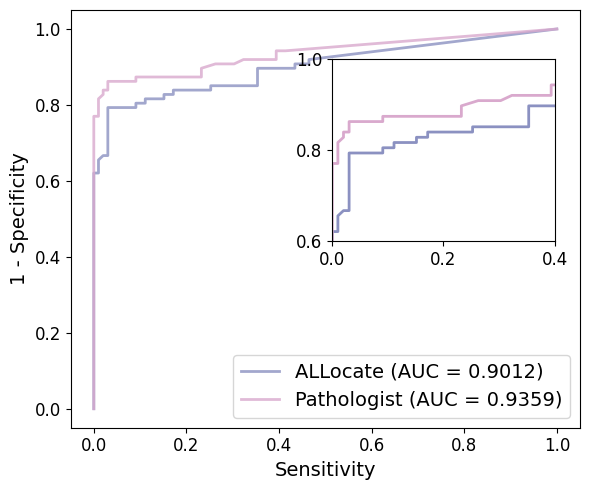

In [8]:
results_dict = {"ALLocate": {
            'mean_fpr': fpr_list_AL,
            'mean_tpr': tpr_list_AL,
            'mean_auc': auc_score_AL}, 
            
            "Pathologist" : {
            'mean_fpr': fpr_list_path,
            'mean_tpr': tpr_list_path,
            'mean_auc': auc_score_path
            }
            }

plot_multi_roc(results_dict=results_dict, zoom_xlim=(0, 0.4), zoom_ylim=(0.6,1.0))